# Fieldlist: Interpolating from hybrid to height levels with interpolate_monotonic

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp
import numpy as np

import earthkit.meteo.vertical.fieldlist as vertical

## Hybrid levels

## Getting the data

The input is GRIB data on 137 IFS model levels for one step. We fetch the file and extract temperature, specific humidity, the surface geopotential and the surface pressure.

In [2]:
fl = ekd.from_source("sample", "tq_ml137_europe.grib2").to_fieldlist()

# LNSP → surface pressure [Pa]
lnsp = fl.sel({"parameter.variable": "lnsp", "vertical.level": 1})[0]
sp = lnsp.set(values=np.exp(lnsp.values))

t = fl.sel({"parameter.variable": "t"})  # temperature, 137 levels
q = fl.sel({"parameter.variable": "q"})  # specific humidity, 137 levels
zs = fl.sel({"parameter.variable": "z", "vertical.level": 1})[0]  # surface geopotential

t.head()

tq_ml137_europe.grib2:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1,hybrid,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,2,hybrid,None,regular_ll
2,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,3,hybrid,None,regular_ll
3,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,4,hybrid,None,regular_ll
4,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5,hybrid,None,regular_ll


The A and B coefficients defining the hybrid levels are embedded in the field metadata and are inferred automatically.

## Using interpolate_monotonic

### Geometric height above the ground

First, compute the geometric height above the ground on all the model levels in the input data. The height type and reference level are controlled by ``h_type`` and ``h_reference``.

In [3]:
h = vertical.height_on_hybrid_levels(t, q, zs, sp, h_type="geometric", h_reference="ground")

Next, interpolate the temperature to the target height levels. 

In [4]:
target_h = [1000.0, 5000.0]  # geometric height (m), above the ground

t_res = vertical.interpolate_monotonic(
    t, coord=h, target_coord=target_h, coord_type="height_above_ground_level", interpolation="linear"
)
t_res.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000.0,height_above_ground_level,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5000.0,height_above_ground_level,None,regular_ll


In [5]:
# the first 2 values from the resulting fields
t_res.values[:, :2]

array([[268.9916733 , 269.2149941 ],
       [246.53155411, 246.83113775]])

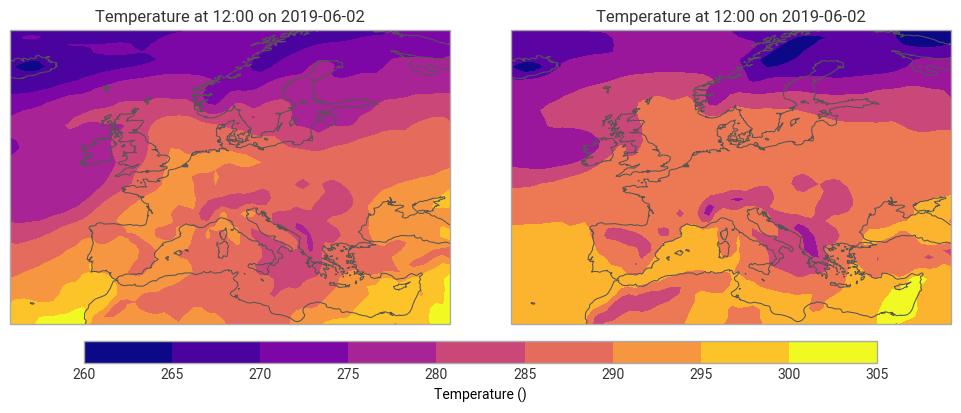

In [6]:
# plot the resulting fields
ekp.quickplot(t_res)

The same computation is repeated with specific humidity (notice the reused height fieldlist).

In [7]:
q_res = vertical.interpolate_monotonic(
    q, coord=h, target_coord=target_h, coord_type="height_above_ground_level", interpolation="linear"
)
q_res.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,q,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000.0,height_above_ground_level,None,regular_ll
1,q,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5000.0,height_above_ground_level,None,regular_ll


In [8]:
# the first 2 values from the resulting fields
q_res.values[:, :2]

array([[0.00279257, 0.00303697],
       [0.00049974, 0.0005222 ]])

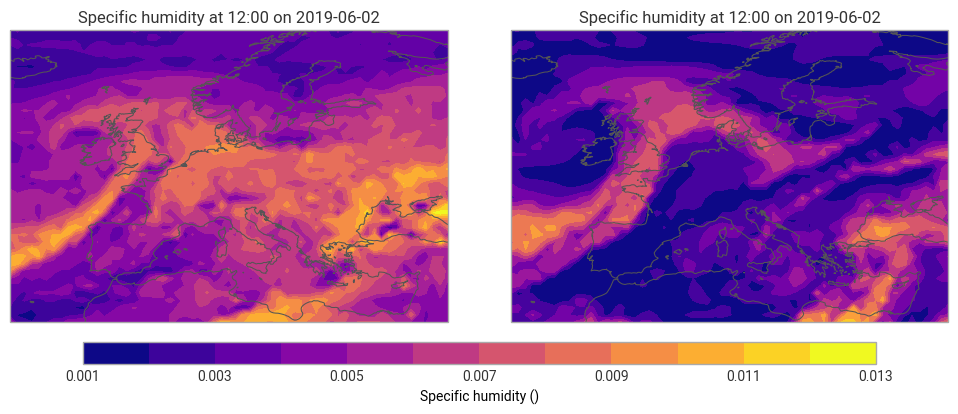

In [9]:
# plot the resulting fields
ekp.quickplot(q_res)

### Geometric height above sea level

In [10]:
target_h_sea = [1000.0, 5000.0]  # geometric height (m), above sea level

h_sea = vertical.height_on_hybrid_levels(t, q, zs, sp, h_type="geometric", h_reference="sea")

t_res_sea = vertical.interpolate_monotonic(
    t, coord=h_sea, target_coord=target_h, coord_type="height_above_sea_level", interpolation="linear"
)
t_res_sea.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000.0,height_above_sea_level,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5000.0,height_above_sea_level,None,regular_ll


In [11]:
# the first 2 values from the resulting fields
t_res_sea.values[:, :2]

array([[268.94972844, 269.35456355],
       [246.48962616, 246.96957874]])

### Geopotential height above the ground

In [12]:
target_h_gp = [1000.0, 5000.0]  # geopotential height (m), above the ground

h_gp = vertical.height_on_hybrid_levels(t, q, zs, sp, h_type="geopotential", h_reference="ground")

t_res_gp = vertical.interpolate_monotonic(
    t, coord=h_gp, target_coord=target_h, coord_type="height_above_ground_level", interpolation="linear"
)
t_res_gp.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000.0,height_above_ground_level,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5000.0,height_above_ground_level,None,regular_ll


In [13]:
# the first 2 values from the resulting fields
t_res_sea.values[:, :2]

array([[268.94972844, 269.35456355],
       [246.48962616, 246.96957874]])

### Using a subset of levels

In [14]:
h[87].values.min()

np.float64(6950.382024204814)

Now we perform the interpolation by using only the lowest 50 model levels.

In [15]:
# keep only the 50 lowest model levels
t_sub = t.sel({"vertical.level": list(range(88, 138))})
q_sub = q.sel({"vertical.level": list(range(88, 138))})

h_sub = vertical.height_on_hybrid_levels(t_sub, q_sub, zs, sp, h_type="geometric", h_reference="ground")


t_res_sub = vertical.interpolate_monotonic(
    t_sub, coord=h_sub, target_coord=target_h, coord_type="height_above_ground_level", interpolation="linear"
)
t_res_sub.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000.0,height_above_ground_level,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5000.0,height_above_ground_level,None,regular_ll


In [16]:
# the first 2 values from the resulting fields
t_res_sub.values[:, :2]

array([[268.9916733 , 269.2149941 ],
       [246.53155411, 246.83113775]])

### Using aux levels

In [17]:
# the height of the first 2 gridpoints (m) on the lowest model level
h[-1].values[:2]

array([9.51766097, 9.50260046])

The lowest model level is approximately 10 m above the ground in the gridpoints we checked. Interpolating to 2 m therefore returns NaN:

In [18]:
target_h_near_surf = [2.0]  # m above the ground

t_res_nan = vertical.interpolate_monotonic(
    t, coord=h, target_coord=target_h_near_surf, coord_type="height_above_ground_level", interpolation="linear"
)

# the first 2 values from the resulting fields
t_res_nan.values[:, :2]

array([[nan, nan]])

To overcome this problem we can supply auxiliary data via the `aux_min_level_coord` and  `aux_min_level_data` kwargs. Both can be a single value (constant) or a field. The example below simply set the temperature at height 0 m (the surface) to slightly higher than at the lowest model level. With this the interpolation works.

In [19]:
t_res_aux = vertical.interpolate_monotonic(
    t,
    coord=h,
    target_coord=target_h_near_surf,
    coord_type="height_above_ground_level",
    aux_min_level_coord=0.0,  # m — height of the auxiliary level (surface)
    aux_min_level_data=t[-1] + 1.0,  # K — set field as temperature at the surface
    interpolation="linear",
)

# the first 2 values from the resulting fields
t_res_aux.values[:, :2]

array([[274.37241439, 273.94922978]])

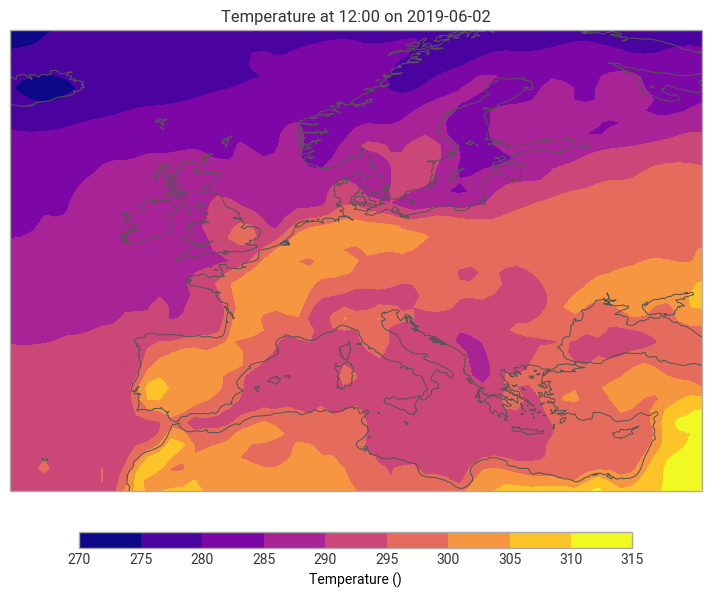

In [20]:
# plot the resulting field
ekp.quickplot(t_res_aux)

### Interpolating to a height field

In [21]:
blh = ekd.from_source("sample", "blh_europe.grib2").to_fieldlist()[0]
blh.ls()

blh_europe.grib2:   0%|          | 0.00/5.04k [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,blh,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,0,surface,0,regular_ll


This field contains heights above ground, so we need to set ``h_reference="ground"`` for the interpolation.

In [22]:
t_res_blh = vertical.interpolate_monotonic(
    t, coord=h, target_coord=blh, coord_type="height_above_ground_level", interpolation="linear"
)
t_res_blh.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,315.217041,height_above_ground_level,None,regular_ll


We plot the boundary layer height and the temperature interpolated to it side by side.

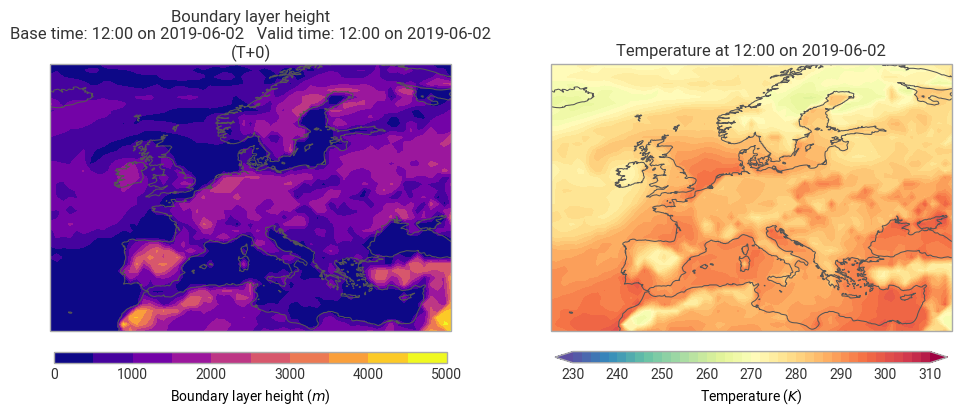

In [23]:
ekp.quickplot(ekd.FieldList.from_fields([blh, t_res_blh]))

## Writing to GRIB

In [24]:
t_res.to_target("file", "_hybrid_to_hl_2.grib")

# read back and verify
t_res_saved = ekd.from_source("file", "_hybrid_to_hl_2.grib").to_fieldlist()
t_res_saved.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000,height_above_ground_level,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5000,height_above_ground_level,None,regular_ll


In [25]:
# the first 2 values from the saved fields
t_res_saved.values[:, :2]

array([[268.99203491, 269.21469116],
       [246.53132629, 246.83113098]])